### imports

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [10]:
def perfilar_dataset_imagenes(ruta_base):
    """
    Escanea la carpeta del dataset de imágenes y genera un resumen de metadatos.
    """
    metadatos = []
    ruta_path = Path(ruta_base)
    extensiones_validas = {'.jpg', '.jpeg', '.png', '.bmp'}
    
    for ruta_img in ruta_path.rglob('*'):
        if ruta_img.suffix.lower() in extensiones_validas:
            categoria = ruta_img.parent.name
            try:
                with Image.open(ruta_img) as img:
                    ancho, alto = img.size
                    modo = img.mode
                    canales = len(img.getbands())
                    peso_kb = os.path.getsize(ruta_img) / 1024
                    
                    metadatos.append({
                        'archivo': ruta_img.name,
                        'categoria': categoria,
                        'ancho': ancho,
                        'alto': alto,
                        'canales': canales,
                        'modo': modo,
                        'peso_kb': peso_kb,
                        'ruta': str(ruta_img),
                        'corrupta': False
                    })
            except Exception as e:
                metadatos.append({
                    'archivo': ruta_img.name,
                    'categoria': categoria,
                    'ruta': str(ruta_img),
                    'corrupta': True,
                    'error': str(e)
                })
                
    df_meta = pd.DataFrame(metadatos)
    
    # Impresión del diagnóstico
    print("=" * 50)
    print("DIAGNÓSTICO GENERAL DEL DATASET DE IMÁGENES")
    print("=" * 50)
    print(f"Total de imágenes detectadas: {len(df_meta)}")
    print(f"Imágenes corruptas: {df_meta['corrupta'].sum()}")
    
    print("\n--- Distribución por Categoría ---")
    print(df_meta['categoria'].value_counts())
    
    print("\n--- Resoluciones/Dimensiones Detectadas ---")
    print(df_meta[['ancho', 'alto', 'canales', 'modo']].drop_duplicates().to_string(index=False))
    
    return df_meta.sample(15)

In [11]:
def mostrar_grid_por_clase(df_meta, cols=5):
    """
    Muestra una cuadrícula con 1 imagen representativa de cada clase.
    """
    df_validas = df_meta[~df_meta['corrupta']]
    clases = df_validas['categoria'].unique()
    filas = (len(clases) + cols - 1) // cols
    
    fig, axes = plt.subplots(filas, cols, figsize=(cols * 3.5, filas * 3.5))
    axes = axes.flatten()
    
    for i, clase in enumerate(clases):
        sub_df = df_validas[df_validas['categoria'] == clase]
        ruta_img = sub_df.iloc[0]['ruta']
        img = Image.open(ruta_img)
        
        axes[i].imshow(img)
        axes[i].set_title(f"{clase}\n{img.size[0]}x{img.size[1]} px", fontsize=9)
        axes[i].axis('off')
        
    # Ocultar subplots vacíos si la cuadrícula es mayor al número de clases
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

#### sample y metadatos

In [20]:
df_meta = perfilar_dataset_imagenes('./data')

DIAGNÓSTICO GENERAL DEL DATASET DE IMÁGENES
Total de imágenes detectadas: 92784
Imágenes corruptas: 0

--- Distribución por Categoría ---
categoria
Tomato_Yellow_Leaf_Curl_Virus227    25716
Bacterial_spot227                   10212
Late_blight227                       9168
Septoria_leaf_spot227                8502
Two-spotted_spider_mite227           8046
healthy227                           7632
Target_Spot227                       6744
Early_blight227                      4800
Leaf_Mold227                         4572
Tomato_mosaic_virus227               1794
powdery mildew                       1413
Bacterial spot                        990
health                                954
Late blight                           882
Gray spot                             756
Black mold                            603
Name: count, dtype: int64

--- Resoluciones/Dimensiones Detectadas ---
 ancho  alto  canales modo
   227   227        3  RGB


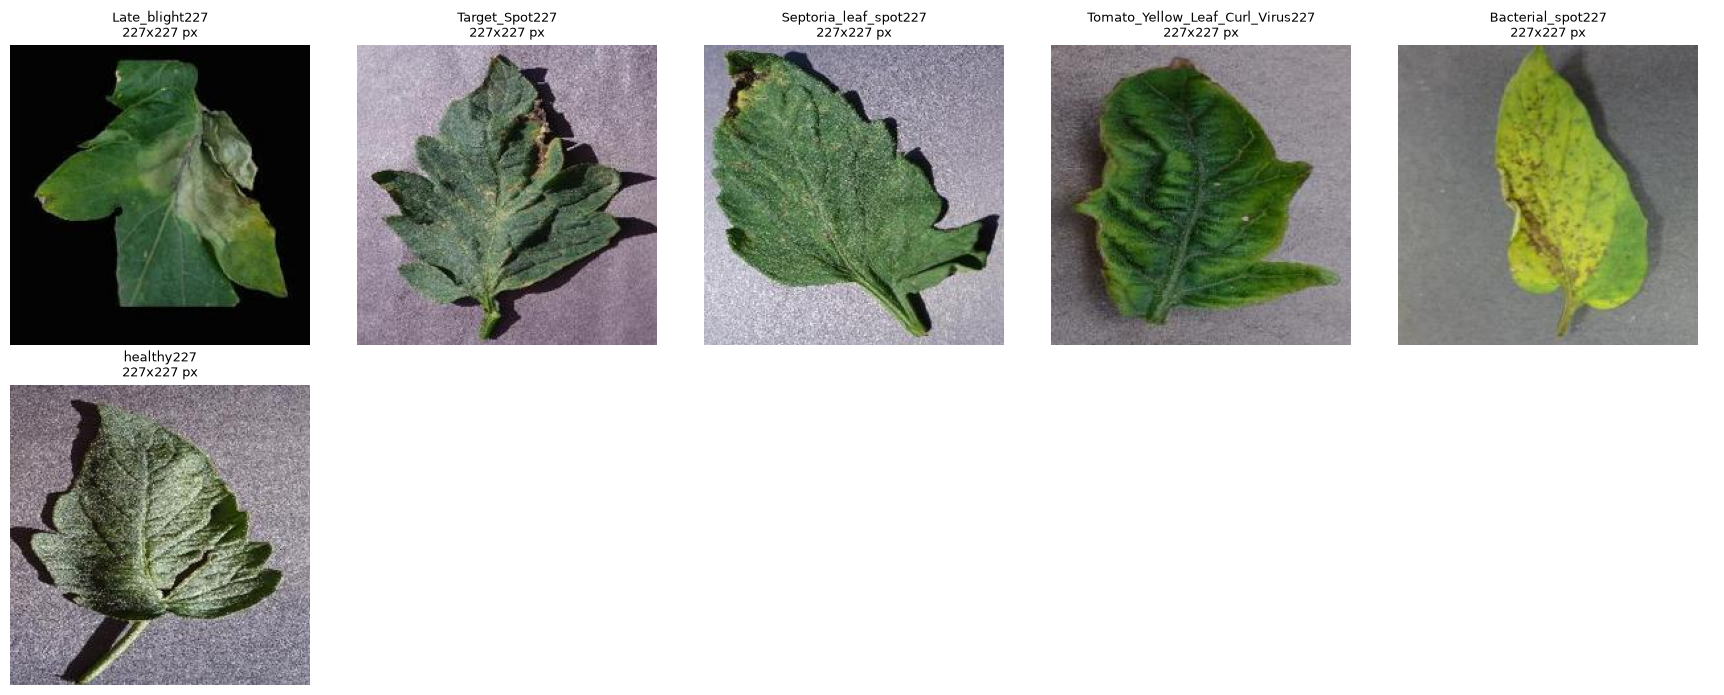

In [21]:
mostrar_grid_por_clase(df_meta)

In [16]:
def resumir_categorias_dataset(base_dir):
    extensiones = {'.jpg', '.jpeg', '.png', '.bmp', '.JPG', '.PNG', '.JPEG'}
    registros = []
    base_path = Path(base_dir)

    # Recorrer de forma recursiva todos los archivos de imagen
    for filepath in base_path.rglob('*'):
        if filepath.suffix in extensiones:
            # Convertir partes de la ruta a minúsculas para comparaciones robustas
            partes_ruta = [p.lower() for p in filepath.parts]
            
            # Categoría: nombre de la carpeta contenedora inmediata
            categoria = filepath.parent.name
            
            # Identificar si está en carpeta preprocesada
            es_preprocesado = any('preprocessed' in p for p in partes_ruta)
            
            # Identificar el conjunto Split
            if 'train' in partes_ruta:
                split = 'Train'
            elif 'test' in partes_ruta:
                split = 'Test'
            else:
                split = 'Sin Split'

            registros.append({
                'Categoria': categoria,
                'Preprocesado': 'Preprocesada' if es_preprocesado else 'No Preprocesada',
                'Split': split
            })

    df = pd.DataFrame(registros)

    if df.empty:
        print("No se encontraron imágenes en el directorio indicado.")
        return None

    # Crear tablas cruzadas para Preprocesamiento y Split
    df_pre = pd.crosstab(df['Categoria'], df['Preprocesado'])
    df_split = pd.crosstab(df['Categoria'], df['Split'])
    df_total = df.groupby('Categoria').size().to_frame(name='Total_Imagenes')

    # Unir todo en una sola vista estructurada
    df_resumen = pd.concat([df_pre, df_split, df_total], axis=1).fillna(0).astype(int)
    
    # Reordenar columnas para lectura clara
    cols_orden = []
    for col in ['No Preprocesada', 'Preprocesada', 'Train', 'Test', 'Sin Split']:
        if col in df_resumen.columns:
            cols_orden.append(col)
    cols_orden.append('Total_Imagenes')
    
    return df_resumen[cols_orden]

# Ejecución del resumen
df_categorias = resumir_categorias_dataset('./data')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
display(df_categorias)

,No Preprocesada,Preprocesada,Train,Test,Sin Split,Total_Imagenes
Categoria,,,,,,
Bacterial spot,880,110,792,198,0,990
Bacterial_spot227,8510,1702,6808,1702,1702,10212
Black mold,536,67,481,122,0,603
Early_blight227,4000,800,3200,800,800,4800
Gray spot,672,84,604,152,0,756
Late blight,784,98,705,177,0,882
Late_blight227,7640,1528,6112,1528,1528,9168
Leaf_Mold227,3810,762,3048,762,762,4572
Septoria_leaf_spot227,7085,1417,5668,1417,1417,8502
